## EJEMPLO DE CÁLCULO Y VISUALIZACiON DE ESFUERZOS.  
#### Soluciones para una fuerza concentrada ubicada en la parte superior de un semiespacio. El origen, 𝐱=(0,0,0) se coloca en la superficie libre, 𝑧 positivo está dentro del medio. Este problema es de interés cuando se modela la deformación/esfuerzo alrededor de una carga localizada, por ejemplo, la carga causada por el peso de un edificio sobre el suelo.
#### Ref: https://continuum-mechanics.readthedocs.io/en/latest/tutorials/point_source_halfspace.html#visualization-of-the-fields

#!pip install --upgrade continuum_mechanics
#!pip install sympy 
import sympy

In [2]:
import numpy as np
from sympy import init_printing, symbols, lambdify, S, simplify
from sympy import pi, Matrix, sqrt, oo

In [3]:
#!pip install continuum_mechanics
import continuum_mechanics
from continuum_mechanics.solids import sym_grad, strain_stress

In [4]:
import matplotlib.pyplot as plt
from matplotlib import colors

In [5]:
# The following snippet allows to format the graphs.
repo = "https://raw.githubusercontent.com/nicoguaro/matplotlib_styles/master"
style = repo + "/styles/minimalist.mplstyle"
plt.style.use(style)

In [6]:
x, y, z, r, E, nu, Fx, Fy, Fz = symbols('x y z r E nu F_x F_y F_z')

The components of the displacement vector are given by (Landau and Lifshitz, Theory of Elasticity Eq. 8.18)

$$
\begin{split}\begin{align}
&u_x = \frac{(1 + \nu)}{2 \pi E}  \left\{\left[\frac{xz}{r^3} - \frac{(1 - 2\nu)x}{r(r + z)}\right]F_z +
  \frac{2(1 - \nu)r +z}{r(r + z)}F_x  +\frac{[2r(\nu r + z) + z^2]x}{r^3(r + z)^2}(xF_x + y F_y)\right\}\, ,\\
&u_y = \frac{(1 + \nu)}{2 \pi E}  \left\{\left[\frac{yz}{r^3} - \frac{(1 - 2\nu)y}{r(r + z)}\right]F_z +
  \frac{2(1 - \nu)r +z}{r(r + z)}F_y  +\frac{[2r(\nu r + z) + z^2]y}{r^3(r + z)^2}(xF_x + y F_y)\right\}\, ,\\
&u_z = \frac{(1 + \nu)}{2 \pi E}  \left\{\left[\frac{2(1 - \nu)}{r} - \frac{z^2}{r^3}\right]F_z  +\left[\frac{1 - 2\nu}{r(r + z)} + \frac{z}{r^3}\right](xF_x +  y F_y)\right\}\, ,
\end{align}\end{split}
$$

In [7]:
ux = (1+nu)/(2*pi*E)*((x*z/r**3 - (1-2*nu)*x/(r*(r + z)))*Fz +
                       (2*(1 - nu)*r + z)/(r*(r + z))*Fx +
                       ((2*r*(nu*r + z) + z**2)*x)/(r**3*(r + z)**2)*(x*Fx + y*Fy))
ux

(nu + 1)*(F_x*(r*(2 - 2*nu) + z)/(r*(r + z)) + F_z*(-x*(1 - 2*nu)/(r*(r + z)) + x*z/r**3) + x*(F_x*x + F_y*y)*(2*r*(nu*r + z) + z**2)/(r**3*(r + z)**2))/(2*pi*E)

In [8]:
uy = (1+nu)/(2*pi*E)*((y*z/r**3 - (1-2*nu)*y/(r*(r + z)))*Fz +
                       (2*(1 - nu)*r + z)/(r*(r + z))*Fy +
                       ((2*r*(nu*r + z) + z**2)*y)/(r**3*(r + z)**2)*(x*Fx + y*Fy))
uy

(nu + 1)*(F_y*(r*(2 - 2*nu) + z)/(r*(r + z)) + F_z*(-y*(1 - 2*nu)/(r*(r + z)) + y*z/r**3) + y*(F_x*x + F_y*y)*(2*r*(nu*r + z) + z**2)/(r**3*(r + z)**2))/(2*pi*E)

In [9]:
uz = (1+nu)/(2*pi*E)*((2*(1 - nu)/r + z**2/r**3)*Fz +
                       ((1 - 2*nu)/(r*(r + z)) + z/r**3)*(x*Fx + y*Fy))
uz

(nu + 1)*(F_z*((2 - 2*nu)/r + z**2/r**3) + (F_x*x + F_y*y)*((1 - 2*nu)/(r*(r + z)) + z/r**3))/(2*pi*E)

In [10]:
# Withouth loss of generality we can assume that 𝐹𝑦=0 this is equivalent a rotate the axes until the force is in the plane 𝑦=0

ux = ux.subs(Fy, 0)
ux

(nu + 1)*(F_x*(r*(2 - 2*nu) + z)/(r*(r + z)) + F_x*x**2*(2*r*(nu*r + z) + z**2)/(r**3*(r + z)**2) + F_z*(-x*(1 - 2*nu)/(r*(r + z)) + x*z/r**3))/(2*pi*E)

In [11]:
uy = ux.subs(Fy, 0)
uy

(nu + 1)*(F_x*(r*(2 - 2*nu) + z)/(r*(r + z)) + F_x*x**2*(2*r*(nu*r + z) + z**2)/(r**3*(r + z)**2) + F_z*(-x*(1 - 2*nu)/(r*(r + z)) + x*z/r**3))/(2*pi*E)

In [12]:
uz = uz.subs(Fy, 0)
uz

(nu + 1)*(F_x*x*((1 - 2*nu)/(r*(r + z)) + z/r**3) + F_z*((2 - 2*nu)/r + z**2/r**3))/(2*pi*E)

In [13]:
#The displacement vector is then
u = Matrix([ux, uy, uz]).subs(r, sqrt(x**2 + y**2 + z**2))

In [14]:
# We can check that the displacement vanish when 𝑥,𝑦,𝑧 →  ∞
u.limit(x, oo)

Matrix([
[0],
[0],
[0]])

In [15]:
u.limit(y, oo)

Matrix([
[0],
[0],
[0]])

In [16]:
u.limit(z, oo)

Matrix([
[0],
[0],
[0]])

In [17]:
# We can compute the strain and stress tensors using the symmetric gradient (vector.sym_grad()) 
# and strain-to-stress (solids.strain_stress()) functions.

In [18]:
lamda = E*nu/((1 + nu)*(1 - 2*nu))
mu = E/(2*(1 - nu))
strain = sym_grad(u)
stress = strain_stress(strain, [lamda, mu])

In [19]:
# The expressions for strains and stresses are lengthy and difficult to work with. 
# Nevertheless, we can work with them. For example, we can evaluate the stress tensor at a point 𝐱=(1,0,1)
# for a vertical load and a Poisson coefficient 𝜈=1/4

In [20]:
simplify(stress.subs({x: 1, y: 0, z:1, nu: S(1)/4, Fx: 0}))

Matrix([
[F_z*(-108 - 73*sqrt(2))/(48*pi*(7 + 5*sqrt(2))), 5*F_z*(-3 - 2*sqrt(2))/(24*pi*(7 + 5*sqrt(2))),   5*F_z*(-3*sqrt(2) - 4)/(16*pi*(2*sqrt(2) + 3))],
[ 5*F_z*(-3 - 2*sqrt(2))/(24*pi*(7 + 5*sqrt(2))), F_z*(-16 - 11*sqrt(2))/(16*pi*(7 + 5*sqrt(2))),                                                0],
[ 5*F_z*(-3*sqrt(2) - 4)/(16*pi*(2*sqrt(2) + 3)),                                              0, F_z*(-148 - 103*sqrt(2))/(48*pi*(7 + 5*sqrt(2)))]])

In [21]:
# Since it is difficult to handle these lengthy expressions we can visualize them. 
# For that, we define a grid where to evaluate the expressions,

#  (𝑥,𝑧)∈[−2,2]×[0,5]

In [22]:
x_vec, z_vec = np.mgrid[-2:2:100j, 0:5:100j]

In [23]:
# We can use lambdify() to turn the SymPy expressions to evaluatable functions.
# Here we input values for Poisson's ratio (nu) and Young's modulus (E)

In [24]:
def field_plot(expr, x_vec, y_vec, z_vec, E_val, nu_val, Fx_val, Fz_val, title=''):
    """Plot the field"""

    # Lambdify the function
    expr_fun = lambdify((x, y, z, E, nu, Fx, Fz), expr, "numpy")
    expr_vec = expr_fun(x_vec, y_vec, z_vec, E_val, nu_val, Fx_val, Fz_val)

    # Determine extrema
    vmin = np.min(expr_vec)
    vmax = np.max(expr_vec)
    print("Minimum value in the domain: {:g}".format(vmin))
    print("Maximum value in the domain: {:g}".format(vmax))
    vmax = max(np.abs(vmax), np.abs(vmin))

    # Plotting
    fig = plt.gcf()
    levels = np.logspace(-1, np.log10(vmax), 10)
    levels = np.hstack((-levels[-1::-1], [0], levels))
    cbar_ticks = ["{:.2g}".format(level) for level in levels]
    cont = plt.contourf(x_vec, z_vec, expr_vec, levels=levels,
                        cmap="RdYlBu_r", norm=colors.SymLogNorm(0.1))
    cbar = fig.colorbar(cont, ticks=levels[::2])
    cbar.ax.set_yticklabels(cbar_ticks[::2])
    plt.axis("image")
    plt.gca().invert_yaxis()
    plt.xlabel(r"$x$")
    plt.ylabel(r"$z$")
    plt.title(title)
    return cont

In [25]:
# Displacements

Minimum value in the domain: 0.0882225
Maximum value in the domain: 16.3306


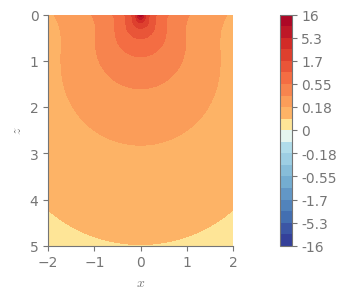

In [26]:
plt.figure()
field_plot(u.norm(), x_vec, 0, z_vec, 1.0, 0.25, 0.0, 1.0)
plt.show()

Minimum value in the domain: -4.92386
Maximum value in the domain: 4.92386


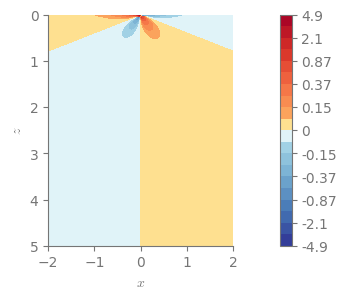

In [27]:
plt.figure()
field_plot(u[0], x_vec, 0, z_vec, 1.0, 0.25, 0.0, 1.0)
plt.show()

Minimum value in the domain: 0.0872617
Maximum value in the domain: 14.7716


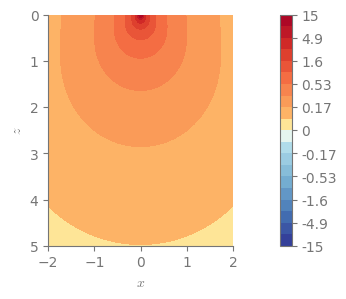

In [28]:
plt.figure()
field_plot(u[2], x_vec, 0, z_vec, 1.0, 0.25, 0.0, 1.0)
plt.show()

In [29]:
# Stresses

Minimum value in the domain: -34.1452
Maximum value in the domain: 422.467
Minimum value in the domain: -10.8361
Maximum value in the domain: 162.487
Minimum value in the domain: -86.1064
Maximum value in the domain: 86.1064
Minimum value in the domain: -42.9687
Maximum value in the domain: 97.4923
Minimum value in the domain: -487.462
Maximum value in the domain: 487.462
Minimum value in the domain: -216.617
Maximum value in the domain: 97.4923


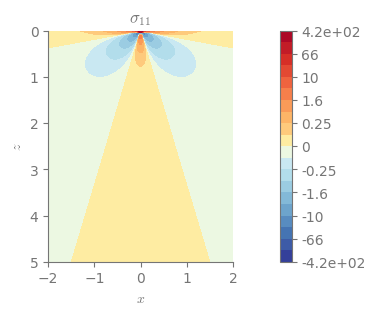

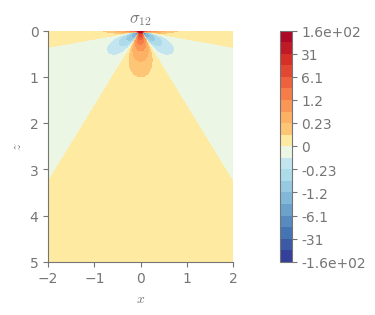

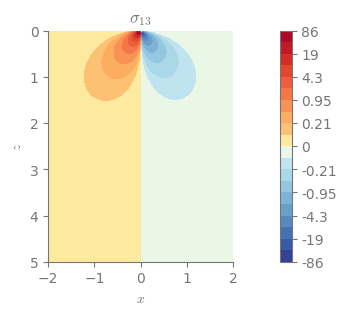

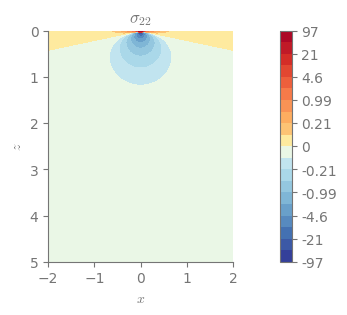

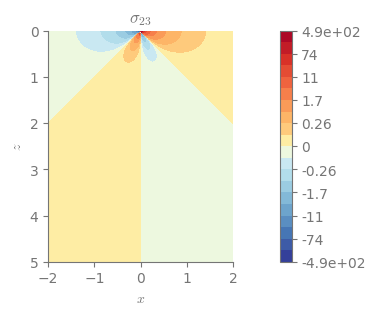

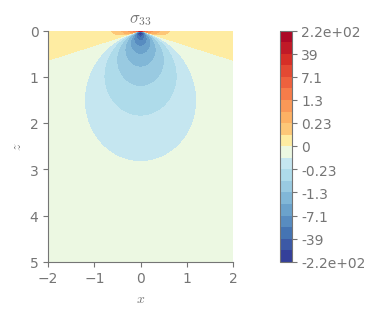

In [30]:
for row in range(0, 3):
    for col in range(row, 3):
        plt.figure()
        field_plot(stress[row,col], x_vec, 0, z_vec, 1.0, 0.25, 0.0, 1.0,
                   title=r"$\sigma_{%i%i}$"%(row+1, col+1))

plt.show()

In [31]:
# Stress invariants
# We can also plot the invariants of the stress tensor
#I1 = S(1)/3 * stress.trace()
#I2 = S(1)/2 * (stress.trace()**2 + (stress**2).trace())  # (stress**2).trace() da problemas
#I3 = stress.det()
#Mises = sqrt(((stress[0,0] - stress[1,1])**2 + (stress[1,1] - stress[2,2])**2 +
#             (stress[2,2] - stress[0,0])**2 +
#             6*(stress[0,1]**2 + stress[1,2]**2 + stress[0,2]**2))/2)


In [32]:
I1 = S(1)/3 * stress.trace()

In [33]:
#I2 = S(1)/2 * (stress.trace()**2 + (stress**2).trace())

In [34]:
#I3 = stress.det()

In [35]:
Mises = sqrt(((stress[0,0] - stress[1,1])**2 + (stress[1,1] - stress[2,2])**2 +
             (stress[2,2] - stress[0,0])**2 +
             6*(stress[0,1]**2 + stress[1,2]**2 + stress[0,2]**2))/2)

Minimum value in the domain: -107.797
Maximum value in the domain: 213.555


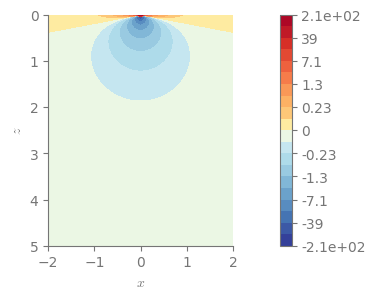

In [36]:
plt.figure()
field_plot(I1, x_vec, 0, z_vec, 1.0, 0.3, 0.0, 1.0)
plt.show()

In [37]:
#plt.figure()
#field_plot(I2, x_vec, 0, z_vec, 1.0, 0.3, 0.0, 1.0)
#plt.show()

In [38]:
#plt.figure()
#field_plot(I3, x_vec, 0, z_vec, 1.0, 0.3, 0.0, 1.0)
#plt.show()

Minimum value in the domain: 0.0274784
Maximum value in the domain: 958.065


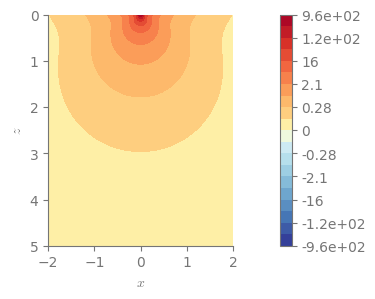

In [39]:
plt.figure()
field_plot(Mises, x_vec, 0, z_vec, 1.0, 0.3, 0.0, 1.0)
plt.show()

In [40]:
?field_plot